In [5]:
#Import necessary libraries
import h5py as h5
import numpy as np
import Spectral_HMM
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

In [6]:
#Get the prepared training data and parameters
with h5.File('../prepare_data/data_d64_m128_lamda0.9_example.h5', 'r') as f:
    data = f['z_train'][:]
    data_val = f['z_test'][:]
    params = eval(f['params'][()])

m = params["m"]
d = params["d"]

print(f"Training Spectral HMM with m={m} and d={d}")
spectral_model = Spectral_HMM.Spectral_HMM(n_observations=m, n_hidden=d)
spectral_model.train(data)

Training Spectral HMM with m=128 and d=64


In [7]:
# Evaluate the model on the validation set

def validation_loss(spectral_model, data_val, m):
    target_data = data_val[:, 1:]   
    output_probabilities = np.zeros((*target_data.shape, m))
    for i in range(data_val.shape[0]):
        output_probabilities[i, :, :] = spectral_model.predict_next(data_val[i])
    probs_t = torch.from_numpy(output_probabilities)
    target_t = torch.from_numpy(target_data).long()
    log_probs_t = torch.log(torch.clamp(probs_t, min=1e-12)).permute(0, 2, 1)
    loss = F.nll_loss(log_probs_t, target_t, reduction='mean')
    return loss

loss = validation_loss(spectral_model, data_val, m)
print(f'Validation loss: {loss.item():.6f}')

Validation loss: 1.852654


In [ ]:
#Train across multiple candidate state dimensions and compare losses
with h5.File('../prepare_data/data_d64_m128_lamda0.9_example.h5', 'r') as f:
    data = f['z_train'][:]
    data_val = f['z_test'][:]
    params = eval(f['params'][()])

dims_and_losses = []
dims = [4,8,16,32,64,128] #dims must be less than or equal to observation dimension m
for d in tqdm(dims):
    spectral_model = Spectral_HMM.Spectral_HMM(n_observations=params['m'], n_hidden=d)
    spectral_model.train(data)
    average_loss = validation_loss(spectral_model, data_val, params['m'])
    dims_and_losses.append((d, average_loss))

print("Best hidden dimension based on validation loss:", min(dims_and_losses, key=lambda x: x[1])[0], "with loss:", min(dims_and_losses, key=lambda x: x[1])[1].item())

100%|██████████| 4/4 [00:33<00:00,  8.44s/it]

Best hidden dimension based on validation loss: 64 with loss: 5.666107252125325


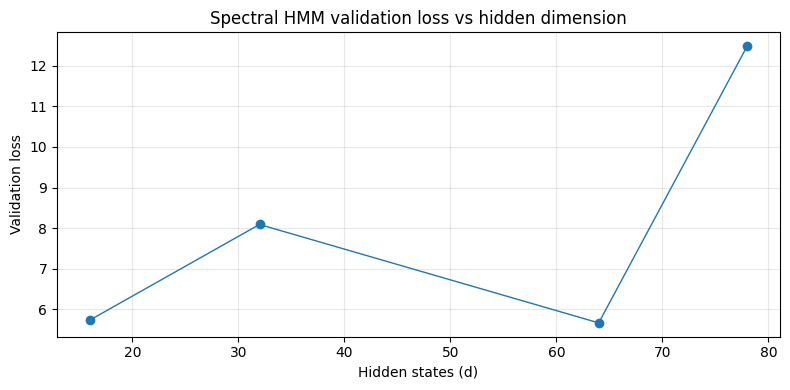

In [ ]:
#Plotting the results
dims, losses = zip(*dims_and_losses)
plt.figure(figsize=(8, 4))
plt.plot(dims, losses, marker='o', linewidth=1)
plt.xlabel('Hidden states (d)')
plt.ylabel('Validation loss')
plt.title('Spectral HMM validation loss vs hidden dimension')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()